In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
baseline = pd.read_csv(
    "baseline_simulation.csv"
)

scenario_a = pd.read_csv(
    "scenario_A_simulation.csv"
)


In [10]:
for df in [
    baseline,
    scenario_a
]:

    for col in [

        "enabled:timestamp",

        "start:timestamp",

        "time:timestamp"

    ]:

        df[col] = pd.to_datetime(
            df[col],
            errors="coerce"
        )

In [11]:
def turnaround_time(df):

    tmp = (

        df

        .groupby(
            "case:concept:name"
        )

        .agg(

            start=(
                "start:timestamp",
                "min"
            ),

            end=(
                "time:timestamp",
                "max"
            )

        )

    )

    return (

        (
            tmp["end"]
            -
            tmp["start"]
        )

        .dt.total_seconds()

        / 60

    )

In [12]:
def waiting_time(df):

    return (

        (
            df["start:timestamp"]
            -
            df["enabled:timestamp"]
        )

        .dt.total_seconds()

        / 60

    ).clip(
        lower=0
    )

In [13]:
def service_time(df):

    return (

        (
            df["time:timestamp"]
            -
            df["start:timestamp"]
        )

        .dt.total_seconds()

        / 60

    ).clip(
        lower=0
    )

In [14]:
results = pd.DataFrame({

    "Metric":[

        "Avg Turnaround",

        "Median Turnaround",

        "Avg Waiting",

        "Median Waiting",

        "Avg Service",

        "Median Service"

    ],

    "Baseline":[

        turnaround_time(
            baseline
        ).mean(),

        turnaround_time(
            baseline
        ).median(),

        waiting_time(
            baseline
        ).mean(),

        waiting_time(
            baseline
        ).median(),

        service_time(
            baseline
        ).mean(),

        service_time(
            baseline
        ).median()

    ],

    "Scenario A":[

        turnaround_time(
            scenario_a
        ).mean(),

        turnaround_time(
            scenario_a
        ).median(),

        waiting_time(
            scenario_a
        ).mean(),

        waiting_time(
            scenario_a
        ).median(),

        service_time(
            scenario_a
        ).mean(),

        service_time(
            scenario_a
        ).median()

    ]

})

results["Difference"] = (

    results["Scenario A"]

    -

    results["Baseline"]

)

results


,Metric,Baseline,Scenario A,Difference
0,Avg Turnaround,40.586630,30.792573,-9.794057
1,Median Turnaround,27.000000,28.000000,1.000000
2,Avg Waiting,9.109526,6.499358,-2.610169
3,Median Waiting,4.000000,4.000000,0.000000
4,Avg Service,5.867628,4.248035,-1.619592
5,Median Service,0.000000,0.000000,0.000000


In [15]:
# Turnaround distribution
baseline_tt = turnaround_time(
    baseline
)

scenario_tt = turnaround_time(
    scenario_a
)

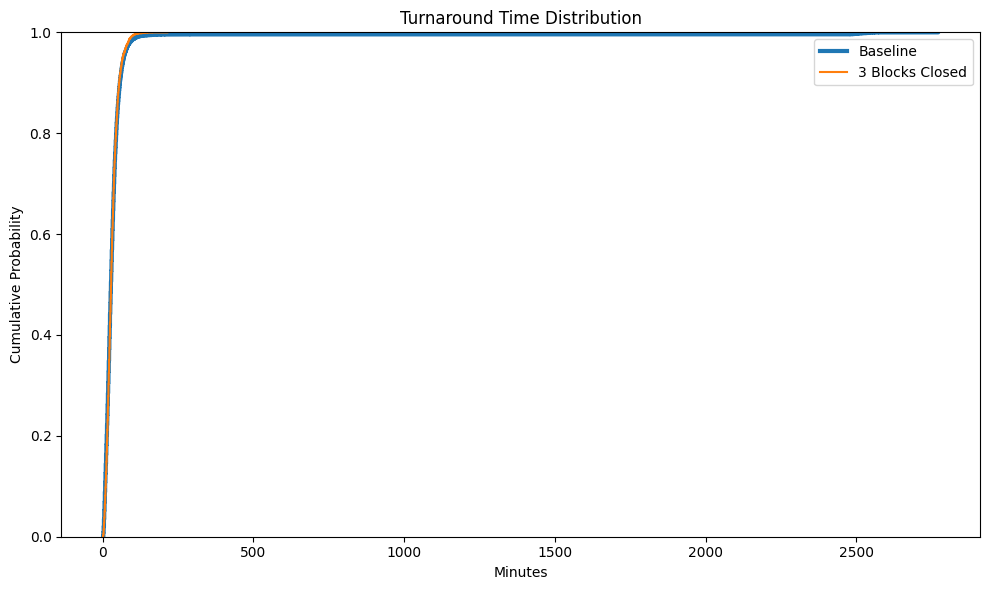

In [16]:
plt.figure(
    figsize=(10,6)
)

sns.ecdfplot(
    baseline_tt,
    label="Baseline",
    linewidth=3
)

sns.ecdfplot(
    scenario_tt,
    label="3 Blocks Closed"
)

plt.title(
    "Turnaround Time Distribution"
)

plt.xlabel(
    "Minutes"
)

plt.ylabel(
    "Cumulative Probability"
)

plt.legend()

plt.tight_layout()

plt.show()

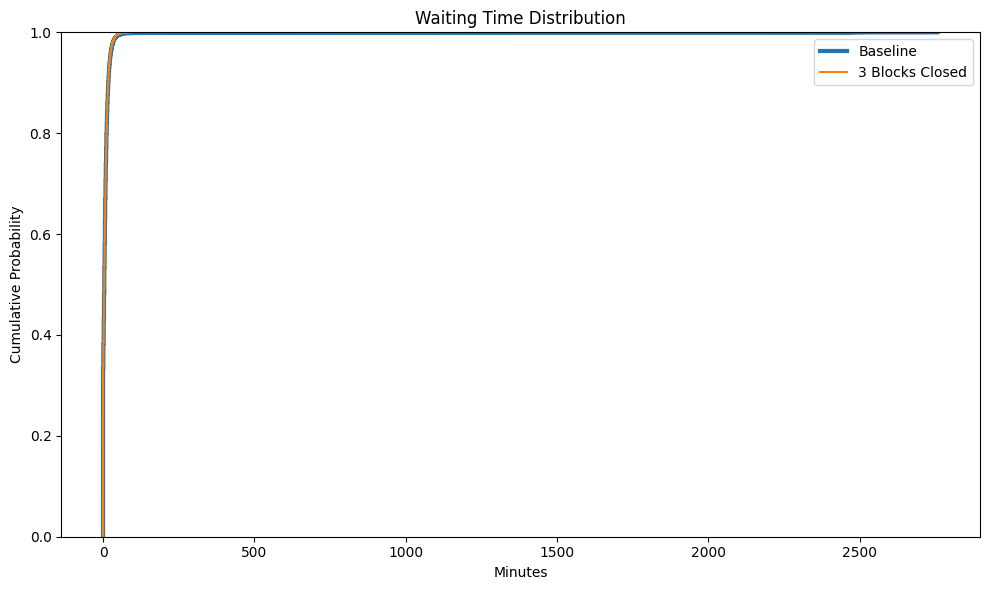

In [17]:
plt.figure(
    figsize=(10,6)
)

sns.ecdfplot(

    waiting_time(
        baseline
    ),

    label="Baseline",
    linewidth=3

)

sns.ecdfplot(

    waiting_time(
        scenario_a
    ),

    label="3 Blocks Closed"

)

plt.title(
    "Waiting Time Distribution"
)

plt.xlabel(
    "Minutes"
)

plt.ylabel(
    "Cumulative Probability"
)

plt.legend()

plt.tight_layout()

plt.show()

In [18]:
activities = [

    "RMG_receive",

    "RMG_delivery",

    "RMG_mixed"

]

In [19]:
rows = []

for act in activities:

    base = baseline[
        baseline["concept:name"]
        ==
        act
    ]

    scen = scenario_a[
        scenario_a["concept:name"]
        ==
        act
    ]

    rows.append({

        "Activity": act,

        "Baseline Waiting":

            waiting_time(
                base
            ).mean(),

        "Scenario Waiting":

            waiting_time(
                scen
            ).mean(),

        "Baseline Service":

            service_time(
                base
            ).mean(),

        "Scenario Service":

            service_time(
                scen
            ).mean()

    })

comparison = pd.DataFrame(
    rows
)

comparison

,Activity,Baseline Waiting,Scenario Waiting,Baseline Service,Scenario Service
0,RMG_receive,14.378670,7.311129,15.715310,11.763607
1,RMG_delivery,13.962904,7.516002,12.471290,8.782706
2,RMG_mixed,12.624576,7.542186,19.001492,14.941306


In [20]:
# PROZENTUALE VERÄNDERUNG
comparison["Waiting Change %"] = (

    (
        comparison["Scenario Waiting"]

        -

        comparison["Baseline Waiting"]

    )

    /

    comparison["Baseline Waiting"]

    * 100

)

comparison["Service Change %"] = (

    (
        comparison["Scenario Service"]

        -

        comparison["Baseline Service"]

    )

    /

    comparison["Baseline Service"]

    * 100

)

In [21]:
# anserwing the research question
comparison[
    [

        "Activity",

        "Waiting Change %",

        "Service Change %"

    ]
]

,Activity,Waiting Change %,Service Change %
0,RMG_receive,-49.152954,-25.145561
1,RMG_delivery,-46.171641,-29.576598
2,RMG_mixed,-40.257905,-21.367720


In [23]:
print(
    baseline["case:concept:name"].nunique()
)

print(
    scenario_a["case:concept:name"].nunique()
)
print(
    baseline["concept:name"]
    .value_counts(normalize=True)
)

print(
    scenario_a["concept:name"]
    .value_counts(normalize=True)
)

20000
5000
Gate In         0.309487
Gate Out        0.309487
RMG_receive     0.164322
RMG_delivery    0.120313
RMG_mixed       0.084320
T23_unknown     0.000882
LL_unknown      0.000867
T10_unknown     0.000851
T25_unknown     0.000836
T12_unknown     0.000696
T20_unknown     0.000696
T22_unknown     0.000681
T08_unknown     0.000650
T19_unknown     0.000542
T09_unknown     0.000542
T27_unknown     0.000511
T11_unknown     0.000449
T16_unknown     0.000433
HO2_unknown     0.000418
T15_unknown     0.000418
T06_unknown     0.000418
T21_unknown     0.000371
T07_unknown     0.000309
T14_unknown     0.000309
T24_unknown     0.000294
T17_unknown     0.000279
T13_unknown     0.000263
T26_unknown     0.000232
T18_unknown     0.000124
Name: concept:name, dtype: float64
Gate In         0.316857
Gate Out        0.316857
RMG_receive     0.156020
RMG_delivery    0.112864
RMG_mixed       0.086375
T24_unknown     0.002852
T27_unknown     0.000697
T12_unknown     0.000697
T20_unknown     0.000570
T19_

In [24]:
print(
    baseline["block_utilization"].describe()
)

print(
    scenario_a["block_utilization"].describe()
)

count    64623.000000
mean         0.610363
std          0.128389
min          0.051830
25%          0.522095
50%          0.612260
75%          0.703877
max          0.838500
Name: block_utilization, dtype: float64
count    15780.000000
mean         0.705804
std          0.147024
min          0.061901
25%          0.604784
50%          0.706915
75%          0.813685
max          0.970895
Name: block_utilization, dtype: float64


In [25]:
print(
    baseline["org:resource"]
    .value_counts(normalize=True)
)

Res.GateIn     0.309487
Res.GateOut    0.309487
T13            0.049719
T14            0.035034
T24            0.031552
T17            0.027250
T16            0.024542
T20            0.017765
T12            0.017765
T21            0.016093
T22            0.015846
T11            0.013819
T23            0.013633
T27            0.013200
T15            0.011389
T06            0.011374
T10            0.011219
T18            0.010461
T09            0.010352
T25            0.010043
T08            0.009950
T07            0.009919
T19            0.009780
T26            0.009037
LL             0.000867
HO2            0.000418
Name: org:resource, dtype: float64


In [26]:
print(
    scenario_a["org:resource"]
    .value_counts(normalize=True)
)

Res.GateIn     0.316857
Res.GateOut    0.316857
T24            0.038086
T23            0.037643
T22            0.035551
T13            0.028137
T14            0.021610
T17            0.017997
T20            0.016160
T16            0.015209
T12            0.013752
T21            0.013561
T09            0.012421
T27            0.012231
T11            0.012167
T15            0.011280
T08            0.011217
T10            0.011027
T19            0.010456
T18            0.010330
T06            0.010139
T26            0.010076
T25            0.009506
T07            0.007034
LL             0.000444
HO2            0.000253
Name: org:resource, dtype: float64


In [28]:
print("Baseline cases",
      baseline["case:concept:name"].nunique())

print("Scenario cases",
      scenario_a["case:concept:name"].nunique())

print(
    baseline["org:resource"]
    .value_counts(normalize=True)
    .head(10)
)

print(
    scenario_a["org:resource"]
    .value_counts(normalize=True)
    .head(10)
)


Baseline cases 20000
Scenario cases 5000
Res.GateIn     0.309487
Res.GateOut    0.309487
T13            0.049719
T14            0.035034
T24            0.031552
T17            0.027250
T16            0.024542
T20            0.017765
T12            0.017765
T21            0.016093
Name: org:resource, dtype: float64
Res.GateIn     0.316857
Res.GateOut    0.316857
T24            0.038086
T23            0.037643
T22            0.035551
T13            0.028137
T14            0.021610
T17            0.017997
T20            0.016160
T16            0.015209
Name: org:resource, dtype: float64


In [29]:
print(
    baseline["block_utilization"]
    .describe()
)

print(
    scenario_a["block_utilization"]
    .describe()
)

count    64623.000000
mean         0.610363
std          0.128389
min          0.051830
25%          0.522095
50%          0.612260
75%          0.703877
max          0.838500
Name: block_utilization, dtype: float64
count    15780.000000
mean         0.705804
std          0.147024
min          0.061901
25%          0.604784
50%          0.706915
75%          0.813685
max          0.970895
Name: block_utilization, dtype: float64
